In [13]:
#Import Libraries
import pandas as pd
import numpy as np

In [14]:
#Load the sales data from a CSV file 
df = pd.read_csv('data/sales_data.csv') 
print(df.head())
print(df.info())

   Order_ID Customer_Name   Product  Quantity  Price Region  Order_Date
0      1001          John    Laptop         1  50000  North  2026-01-10
1      1002         Alice     Mouse         2    500  South  2026-01-11
2      1003           NaN  Keyboard         1   1500   West  2026-01-12
3      1004           Raj    Laptop        -1  50000  North  2026-01-13
4      1005          Neha   Monitor         1  10000   East  2026-01-14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order_ID       6 non-null      int64 
 1   Customer_Name  5 non-null      object
 2   Product        6 non-null      object
 3   Quantity       6 non-null      int64 
 4   Price          6 non-null      int64 
 5   Region         6 non-null      object
 6   Order_Date     6 non-null      object
dtypes: int64(3), object(4)
memory usage: 464.0+ bytes
None


In [15]:
#Data Cleaning
print(df.isnull().sum())

Order_ID         0
Customer_Name    1
Product          0
Quantity         0
Price            0
Region           0
Order_Date       0
dtype: int64


In [17]:
#Fill missing values
df["Customer_Name"] = df["Customer_Name"].fillna("Unknown")
df

,Order_ID,Customer_Name,Product,Quantity,Price,Region,Order_Date
0,1001,John,Laptop,1,50000,North,2026-01-10
1,1002,Alice,Mouse,2,500,South,2026-01-11
2,1003,Unknown,Keyboard,1,1500,West,2026-01-12
3,1004,Raj,Laptop,-1,50000,North,2026-01-13
4,1005,Neha,Monitor,1,10000,East,2026-01-14


In [16]:
#Remove duplicates
df = df.drop_duplicates()
len(df)

5

In [18]:
#Remove Invalid Data
df = df[df["Quantity"] > 0]
df

,Order_ID,Customer_Name,Product,Quantity,Price,Region,Order_Date
0,1001,John,Laptop,1,50000,North,2026-01-10
1,1002,Alice,Mouse,2,500,South,2026-01-11
2,1003,Unknown,Keyboard,1,1500,West,2026-01-12
4,1005,Neha,Monitor,1,10000,East,2026-01-14


In [7]:
#Remove Extra Spaces
df["Product"] = df["Product"].str.strip()
df["Region"] = df["Region"].str.strip()

In [9]:
#Convert Date column to datetime format
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df

,Order_ID,Customer_Name,Product,Quantity,Price,Region,Order_Date
0,1001,John,Laptop,1,50000,North,2026-01-10
1,1002,Alice,Mouse,2,500,South,2026-01-11
2,1003,Unknown,Keyboard,1,1500,West,2026-01-12
3,1004,Raj,Laptop,-1,50000,North,2026-01-13
4,1005,Neha,Monitor,1,10000,East,2026-01-14


In [19]:
#Create Revenue column
df["Revenue"] = df["Quantity"] * df["Price"]
df

C:\Users\ASUS\AppData\Local\Temp\ipykernel_8620\2415297794.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Revenue"] = df["Quantity"] * df["Price"]


,Order_ID,Customer_Name,Product,Quantity,Price,Region,Order_Date,Revenue
0,1001,John,Laptop,1,50000,North,2026-01-10,50000
1,1002,Alice,Mouse,2,500,South,2026-01-11,1000
2,1003,Unknown,Keyboard,1,1500,West,2026-01-12,1500
4,1005,Neha,Monitor,1,10000,East,2026-01-14,10000


In [20]:
#Total Revenue
df["Revenue"].sum()

np.int64(62500)

In [21]:
#Product-wise Revenue
product_sales = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)
print(product_sales)

Product
Laptop      50000
Monitor     10000
Keyboard     1500
Mouse        1000
Name: Revenue, dtype: int64


In [22]:
#Region-wise Revenue
region_sales = df.groupby("Region")["Revenue"].sum().sort_values(ascending=True)
print(region_sales)

Region
South     1000
West      1500
East     10000
North    50000
Name: Revenue, dtype: int64


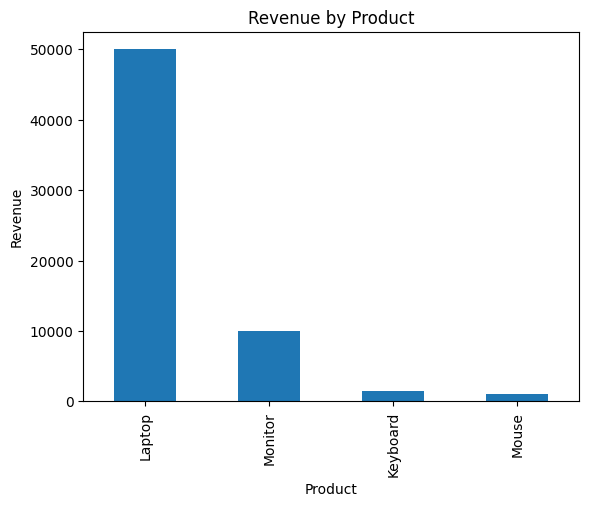

In [23]:
#Create Visualizations
import matplotlib.pyplot as plt
product_sales.plot(kind='bar')
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

In [25]:
#Save the cleaned data to a new CSV file
df.to_csv('output/cleaned_sales_data.csv', index=False)